1. Install and import required libraries

In [1]:
# Install xgboost if needed
!pip -q install xgboost

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

RANDOM_STATE = 42

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

2. Load the Loan Approval dataset

In [2]:
DATA_URL = "https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv"

try:
    df = pd.read_csv(DATA_URL)
    print("Dataset loaded successfully from GitHub.")
except Exception as e:
    print("Online loading failed:", e)
    print("Please upload the loan approval CSV file manually.")
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)
df.head()

Dataset loaded successfully from GitHub.
Dataset shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


3. Dataset overview and real-world business problem

In [3]:
# Show columns, non-null counts and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
# Summary statistics for numerical columns
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP001002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0


4. Identify data types

In [5]:
data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Detected dtype": df.dtypes.astype(str).values,
    "Analytical role": [
        "Identifier - remove before modelling" if col == "Loan_ID" else
        "Target variable - binary classification" if col == "Loan_Status" else
        "Numerical feature" if col in ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"] else
        "Ordinal-like categorical feature" if col == "Dependents" else
        "Categorical / binary feature"
        for col in df.columns
    ]
})
data_dictionary

,Column,Detected dtype,Analytical role
0,Loan_ID,object,Identifier - remove before modelling
1,Gender,object,Categorical / binary feature
2,Married,object,Categorical / binary feature
3,Dependents,object,Ordinal-like categorical feature
4,Education,object,Categorical / binary feature
5,Self_Employed,object,Categorical / binary feature
6,ApplicantIncome,int64,Numerical feature
7,CoapplicantIncome,float64,Numerical feature
8,LoanAmount,float64,Numerical feature
9,Loan_Amount_Term,float64,Numerical feature


5. Check missing values, duplicates, cleaning and encoding needs

In [6]:
# Missing value check
missing_summary = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Missing percentage": (df.isna().mean() * 100).round(2)
}).sort_values("Missing values", ascending=False)

missing_summary

,Missing values,Missing percentage
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49
Loan_ID,0,0.00
Education,0,0.00
ApplicantIncome,0,0.00


In [7]:
# Duplicate row check
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


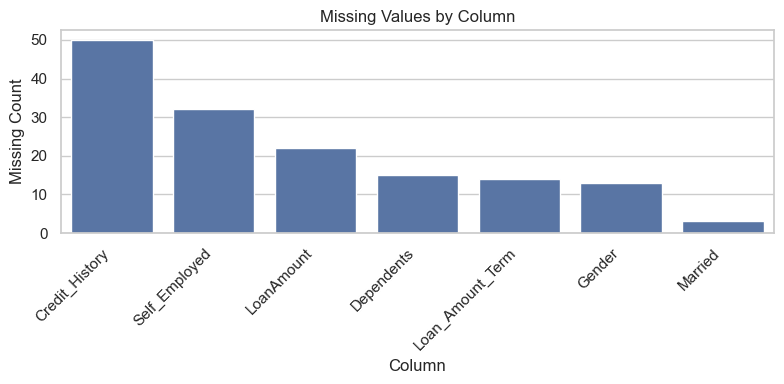

In [8]:
# Visualize missing values
missing_summary_plot = missing_summary[missing_summary["Missing values"] > 0]

plt.figure(figsize=(8, 4))
sns.barplot(x=missing_summary_plot.index, y=missing_summary_plot["Missing values"])
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

6. Exploratory Data Analysis (EDA)

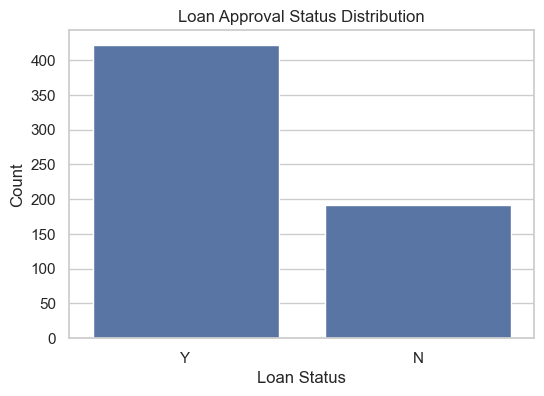

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [9]:
# Target distribution
target_counts = df["Loan_Status"].value_counts()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Loan_Status")
plt.title("Loan Approval Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

target_counts

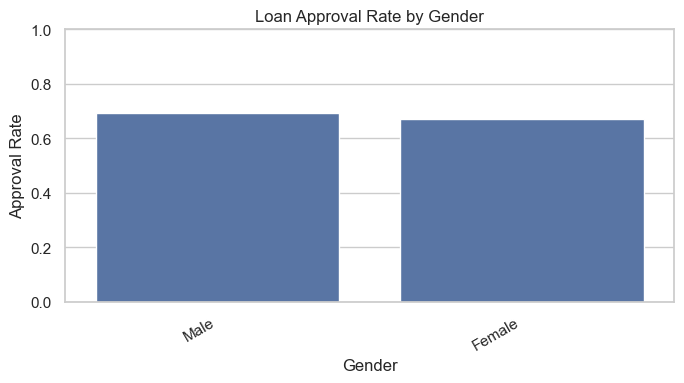

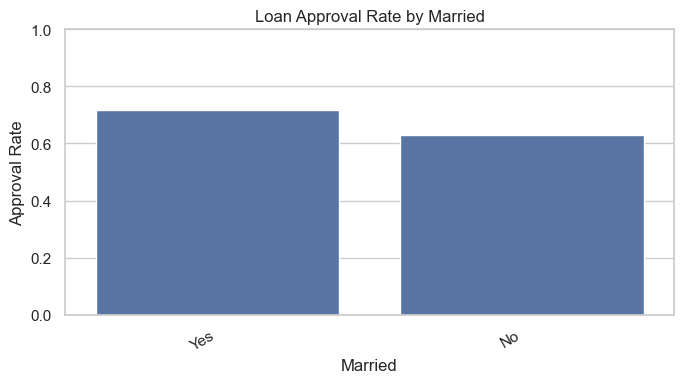

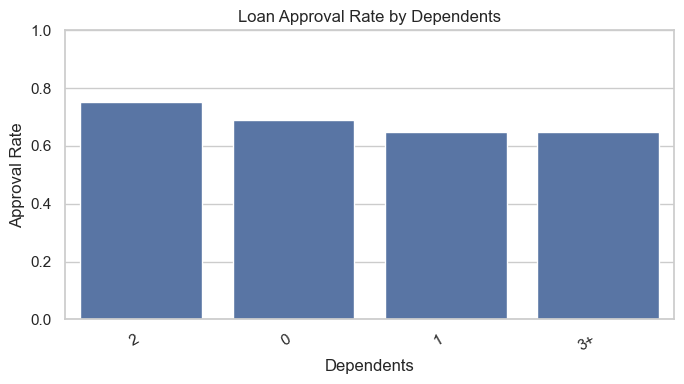

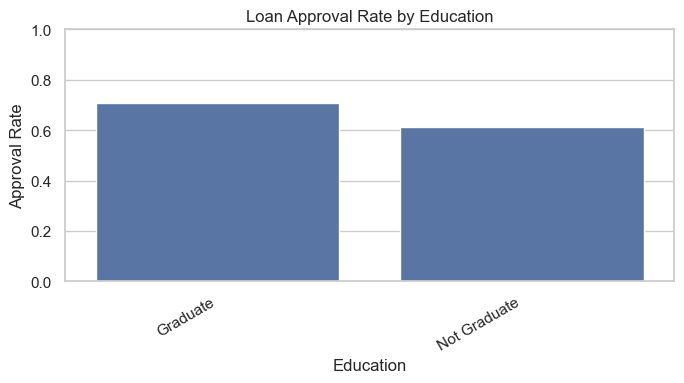

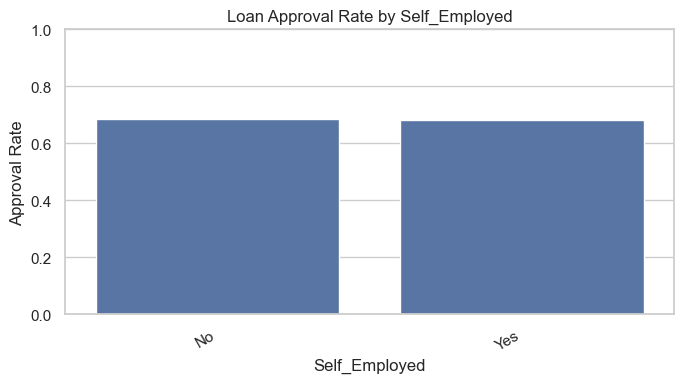

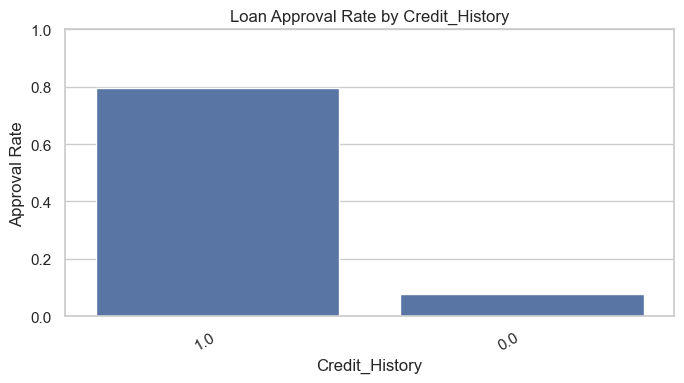

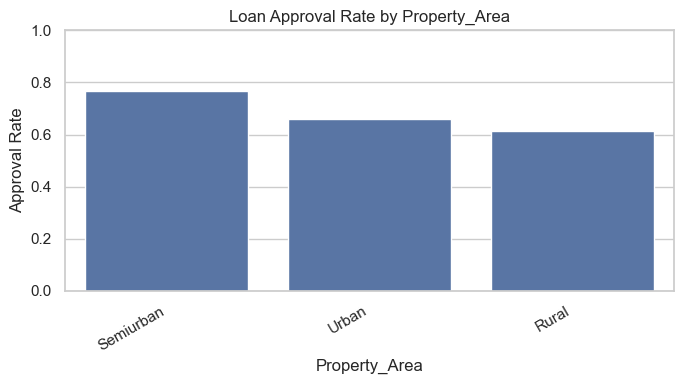

In [10]:
# Approval rate by selected categorical variables
categorical_eda_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Credit_History", "Property_Area"]

for col in categorical_eda_cols:
    plt.figure(figsize=(7, 4))
    approval_rate = df.groupby(col)["Loan_Status"].apply(lambda x: (x == "Y").mean()).sort_values(ascending=False)
    sns.barplot(x=approval_rate.index.astype(str), y=approval_rate.values)
    plt.title(f"Loan Approval Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Approval Rate")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

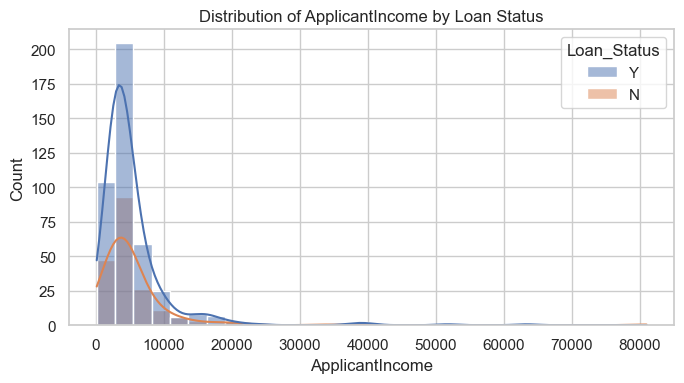

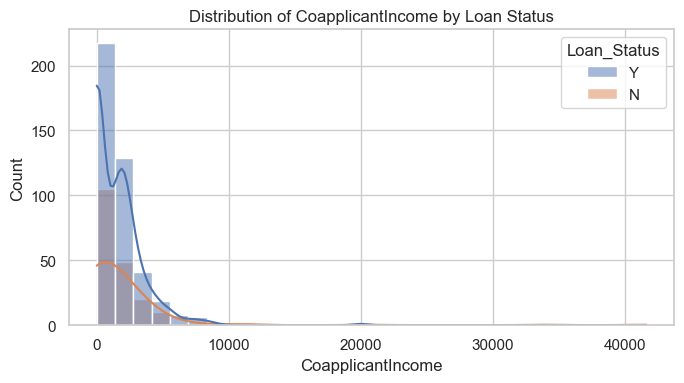

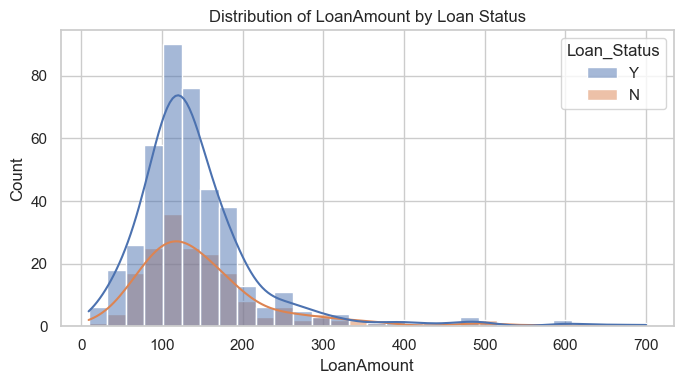

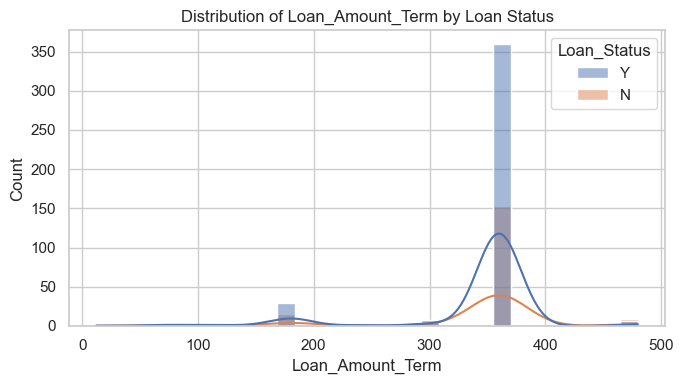

In [11]:
# Numerical distributions by loan status
numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, hue="Loan_Status", kde=True, bins=30)
    plt.title(f"Distribution of {col} by Loan Status")
    plt.tight_layout()
    plt.show()

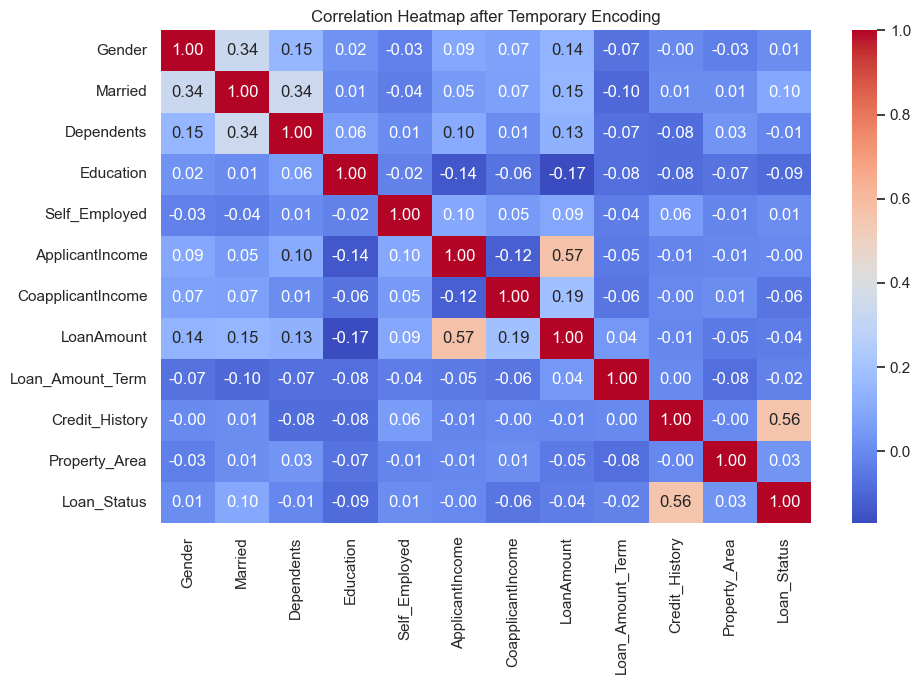

In [12]:
# Correlation heatmap after temporary label encoding for EDA only
df_corr = df.copy()
for col in df_corr.columns:
    if df_corr[col].dtype == "object":
        df_corr[col] = df_corr[col].astype(str)
        df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

plt.figure(figsize=(10, 7))
sns.heatmap(df_corr.drop(columns=["Loan_ID"], errors="ignore").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap after Temporary Encoding")
plt.tight_layout()
plt.show()

7. Prepare data for machine learning

In [13]:
# Copy data
model_df = df.copy()

# Drop identifier
model_df = model_df.drop(columns=["Loan_ID"], errors="ignore")

# Map target
model_df["Loan_Status"] = model_df["Loan_Status"].map({"N": 0, "Y": 1})

# Define features and target
X = model_df.drop(columns=["Loan_Status"])
y = model_df["Loan_Status"]

# Define feature groups
numeric_features = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
categorical_features = [col for col in X.columns if col not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target classes:", y.value_counts().to_dict())

Numeric features: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
Categorical features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']
Target classes: {1: 422, 0: 192}


In [14]:
# Train/test split with stratification to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("Testing target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training shape: (491, 11)
Testing shape: (123, 11)
Training target distribution:
Loan_Status
1    0.686
0    0.314
Name: proportion, dtype: float64
Testing target distribution:
Loan_Status
1    0.691
0    0.309
Name: proportion, dtype: float64


In [15]:
# Create OneHotEncoder with compatibility for different sklearn versions
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer_svm = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

# SVM benefits from scaling numerical variables
preprocessor_svm = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_svm, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Tree models do not require scaling, but still need imputation and encoding
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

8. Task 2: Support Vector Machine classification model

In [16]:
# Build SVM model
svm_model = Pipeline(steps=[
    ("preprocess", preprocessor_svm),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE))
])

# Train model
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Evaluation
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("SVM Model Performance")
print("---------------------")
print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("F1-score :", round(svm_f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=["Rejected", "Approved"]))

SVM Model Performance
---------------------
Accuracy : 0.8455
Precision: 0.8235
Recall   : 0.9882
F1-score : 0.8984

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.95      0.53      0.68        38
    Approved       0.82      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.76      0.79       123
weighted avg       0.86      0.85      0.83       123



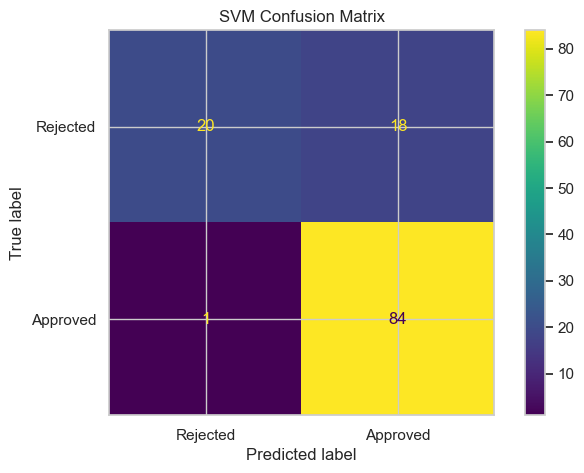

In [17]:
# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Rejected", "Approved"])
disp.plot(values_format="d")
plt.title("SVM Confusion Matrix")
plt.show()

9. 3D visualization of classes and SVM decision boundary

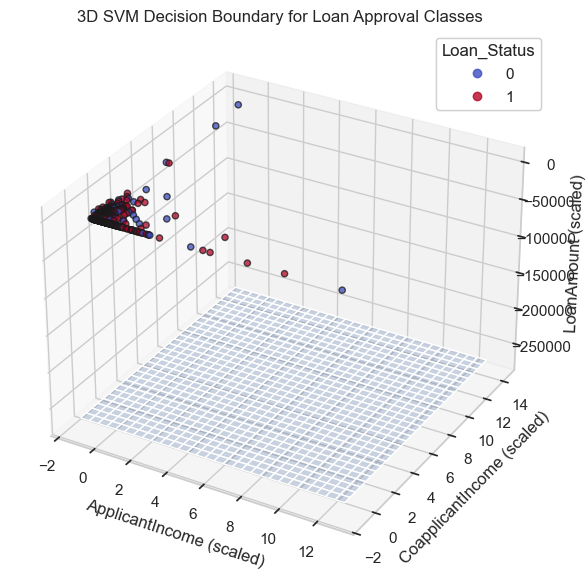

In [18]:
# Prepare 3D data using three numerical variables
three_features = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]

visual_df = model_df[three_features + ["Loan_Status"]].copy()

# Impute missing values for visualization
for col in three_features:
    visual_df[col] = visual_df[col].fillna(visual_df[col].median())

X_3d = visual_df[three_features]
y_3d = visual_df["Loan_Status"]

# Scale three selected features
scaler_3d = StandardScaler()
X_3d_scaled = scaler_3d.fit_transform(X_3d)

# Linear SVM for visible boundary plane
svm_3d = SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE)
svm_3d.fit(X_3d_scaled, y_3d)

# Coefficients of decision plane: w0*x + w1*y + w2*z + b = 0
w = svm_3d.coef_[0]
b = svm_3d.intercept_[0]

# Create grid for x and y, calculate z
x_min, x_max = X_3d_scaled[:, 0].min() - 0.5, X_3d_scaled[:, 0].max() + 0.5
y_min, y_max = X_3d_scaled[:, 1].min() - 0.5, X_3d_scaled[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 30),
                     np.linspace(y_min, y_max, 30))

if abs(w[2]) > 1e-6:
    zz = -(w[0] * xx + w[1] * yy + b) / w[2]

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    scatter = ax.scatter(
        X_3d_scaled[:, 0],
        X_3d_scaled[:, 1],
        X_3d_scaled[:, 2],
        c=y_3d,
        cmap="coolwarm",
        alpha=0.75,
        edgecolor="k"
    )

    ax.plot_surface(xx, yy, zz, alpha=0.25)

    ax.set_xlabel("ApplicantIncome (scaled)")
    ax.set_ylabel("CoapplicantIncome (scaled)")
    ax.set_zlabel("LoanAmount (scaled)")
    ax.set_title("3D SVM Decision Boundary for Loan Approval Classes")

    legend1 = ax.legend(*scatter.legend_elements(), title="Loan_Status")
    ax.add_artist(legend1)

    plt.show()
else:
    print("The selected features produced a near-vertical boundary that cannot be displayed as z=f(x,y).")
    print("Try changing the three_features list.")

10. XGBoost model with hyperparameter optimization

In [19]:
# Define XGBoost pipeline
xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor_tree),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Hyperparameter grid required by the brief
param_grid = {
    "model__n_estimators": [50, 100, 150, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.10, 0.20, 0.30]
}

# Grid search with cross-validation
xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost parameters:", xgb_grid.best_params_)
print("Best cross-validation F1-score:", round(xgb_grid.best_score_, 4))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best XGBoost parameters: {'model__learning_rate': 0.01, 'model__n_estimators': 100}
Best cross-validation F1-score: 0.8678


In [20]:
# Evaluate best XGBoost model on test set
best_xgb_model = xgb_grid.best_estimator_

y_pred_xgb = best_xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("XGBoost Model Performance")
print("-------------------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1-score :", round(xgb_f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=["Rejected", "Approved"]))

XGBoost Model Performance
-------------------------
Accuracy : 0.8618
Precision: 0.84
Recall   : 0.9882
F1-score : 0.9081

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.96      0.58      0.72        38
    Approved       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



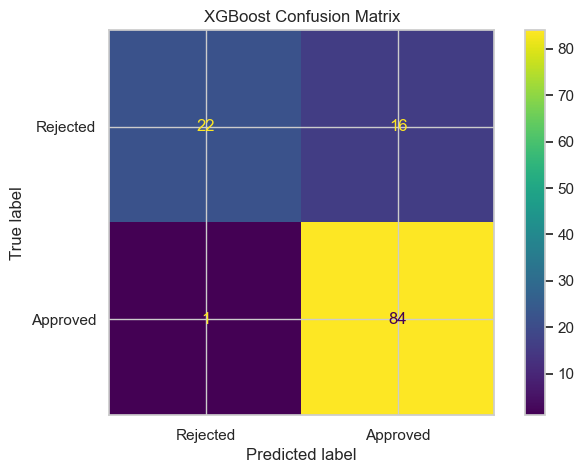

In [21]:
# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["Rejected", "Approved"])
disp.plot(values_format="d")
plt.title("XGBoost Confusion Matrix")
plt.show()

11. Visualize XGBoost optimization results

In [22]:
# Convert GridSearchCV results into a dataframe
cv_results = pd.DataFrame(xgb_grid.cv_results_)

optimization_results = cv_results[[
    "param_model__n_estimators",
    "param_model__learning_rate",
    "mean_test_score",
    "std_test_score",
    "mean_train_score"
]].copy()

optimization_results.columns = [
    "n_estimators",
    "learning_rate",
    "mean_cv_f1",
    "std_cv_f1",
    "mean_train_f1"
]

optimization_results["prediction_error"] = 1 - optimization_results["mean_cv_f1"]

optimization_results = optimization_results.sort_values("mean_cv_f1", ascending=False)
optimization_results.head(10)

,n_estimators,learning_rate,mean_cv_f1,std_cv_f1,mean_train_f1,prediction_error
1,100,0.01,0.867778,0.012230,0.879150,0.132222
2,150,0.01,0.865506,0.011395,0.888552,0.134494
5,50,0.05,0.861431,0.012551,0.914076,0.138569
3,200,0.01,0.860975,0.014018,0.902918,0.139025
0,50,0.01,0.859195,0.012154,0.870051,0.140805
4,300,0.01,0.856765,0.016180,0.920425,0.143235
6,100,0.05,0.845023,0.023051,0.964810,0.154977
7,150,0.05,0.844941,0.029951,0.984666,0.155059
15,50,0.20,0.840274,0.022001,0.991557,0.159726
10,50,0.10,0.840222,0.024512,0.962071,0.159778


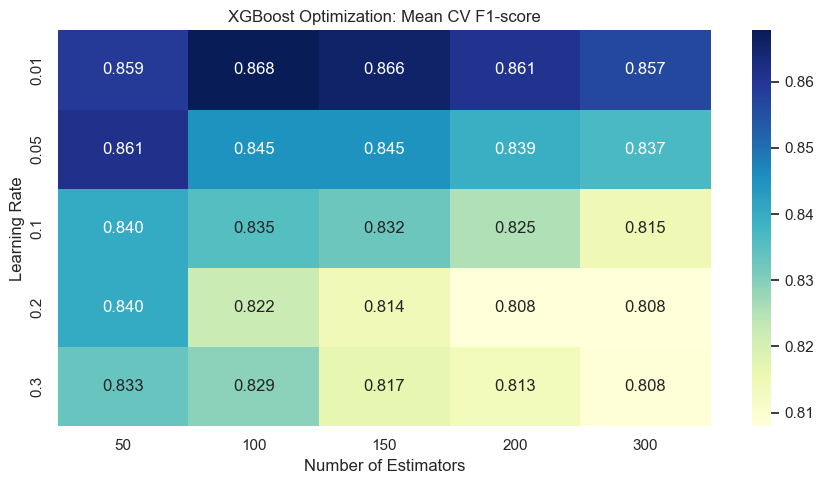

In [23]:
# Heatmap of F1-score by hyperparameter combination
pivot_f1 = optimization_results.pivot(
    index="learning_rate",
    columns="n_estimators",
    values="mean_cv_f1"
).sort_index(ascending=True)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("XGBoost Optimization: Mean CV F1-score")
plt.xlabel("Number of Estimators")
plt.ylabel("Learning Rate")
plt.tight_layout()
plt.show()

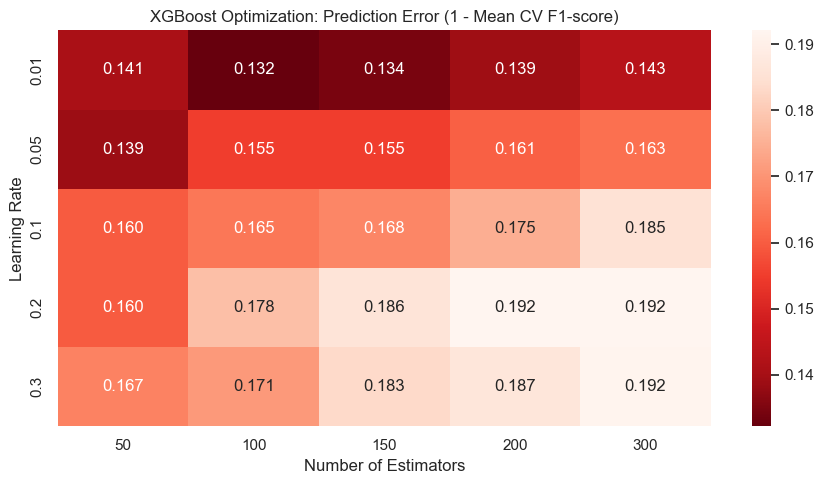

In [24]:
# Heatmap of prediction error
pivot_error = optimization_results.pivot(
    index="learning_rate",
    columns="n_estimators",
    values="prediction_error"
).sort_index(ascending=True)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot_error, annot=True, fmt=".3f", cmap="Reds_r")
plt.title("XGBoost Optimization: Prediction Error (1 - Mean CV F1-score)")
plt.xlabel("Number of Estimators")
plt.ylabel("Learning Rate")
plt.tight_layout()
plt.show()

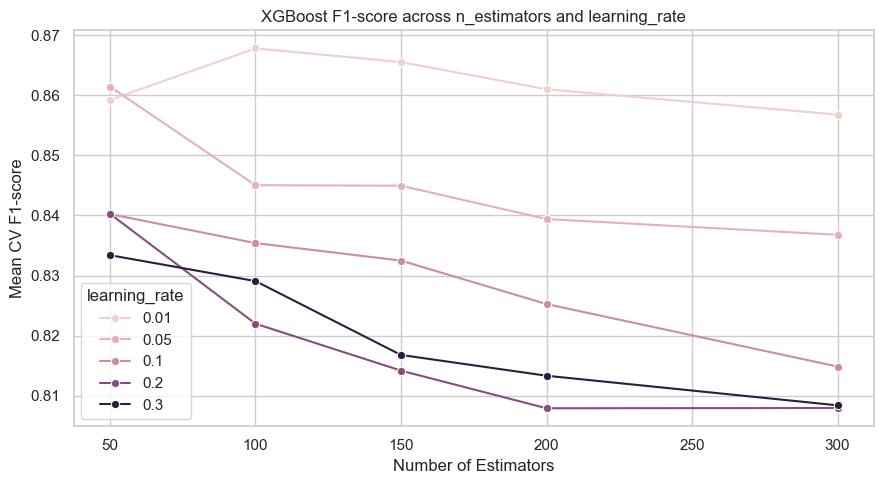

In [25]:
# Line plot to compare learning rates across estimator values
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=optimization_results,
    x="n_estimators",
    y="mean_cv_f1",
    hue="learning_rate",
    marker="o"
)
plt.title("XGBoost F1-score across n_estimators and learning_rate")
plt.xlabel("Number of Estimators")
plt.ylabel("Mean CV F1-score")
plt.tight_layout()
plt.show()

12. XGBoost feature importance

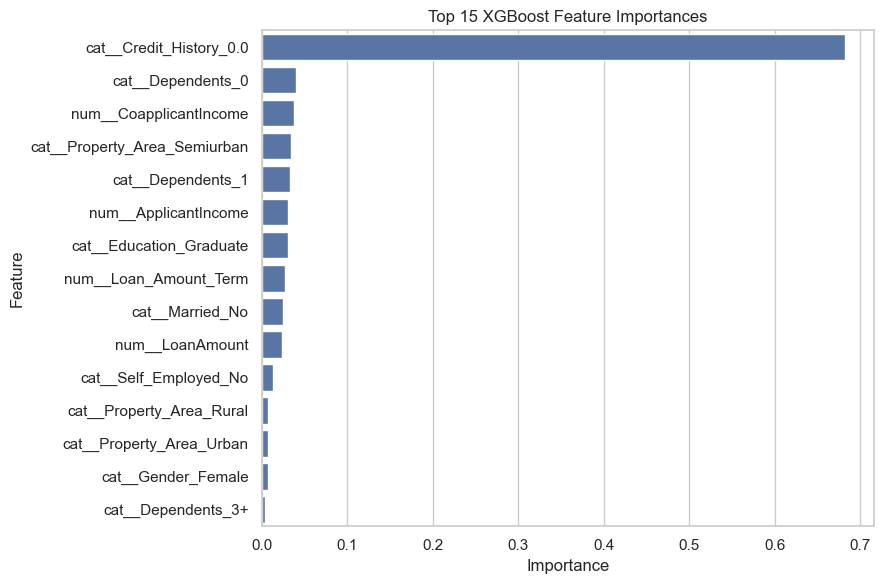

In [26]:
# Try to extract transformed feature names and plot feature importance
try:
    feature_names = best_xgb_model.named_steps["preprocess"].get_feature_names_out()
    importances = best_xgb_model.named_steps["model"].feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=importance_df, x="importance", y="feature")
    plt.title("Top 15 XGBoost Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    importance_df
except Exception as e:
    print("Feature importance plot could not be generated:", e)

13. Model comparison and business interpretation

In [27]:
comparison_df = pd.DataFrame({
    "Model": ["SVM", "XGBoost"],
    "Accuracy": [svm_accuracy, xgb_accuracy],
    "Precision": [svm_precision, xgb_precision],
    "Recall": [svm_recall, xgb_recall],
    "F1-score": [svm_f1, xgb_f1]
})

comparison_df_rounded = comparison_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-score"]:
    comparison_df_rounded[col] = comparison_df_rounded[col].round(4)

comparison_df_rounded

,Model,Accuracy,Precision,Recall,F1-score
0,SVM,0.8455,0.8235,0.9882,0.8984
1,XGBoost,0.8618,0.8400,0.9882,0.9081


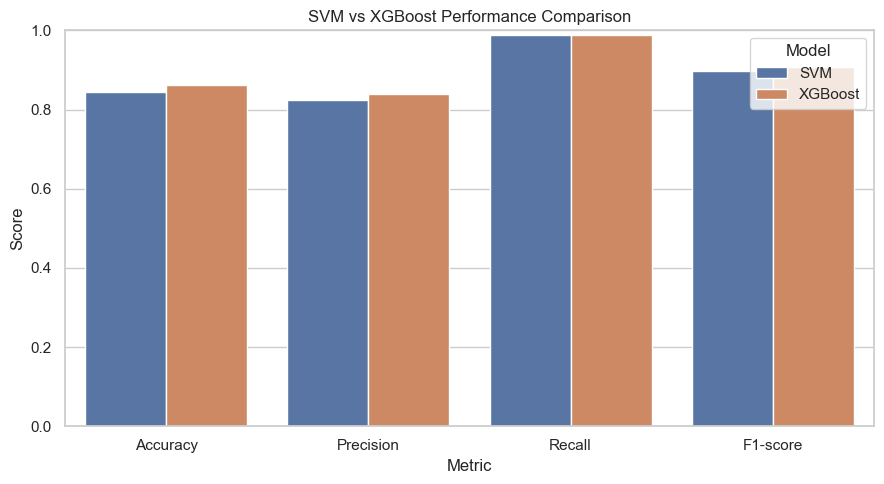

In [28]:
# Visual comparison
comparison_long = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_long, x="Metric", y="Score", hue="Model")
plt.title("SVM vs XGBoost Performance Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()